### Creating a Graph in PyTorch

Let's look at a simple example that illustrates how to create a graph in PyTorch for evaluating $z = 2 \times (a-b) + c$. The variables $a, b,$ and $c$ are scalars (single numbers), and we define these as PyTorch tensors. To create the graph, we can simply define a regular Python function with $a, b,$ and $c$ as its input argument, for example:

In [1]:
import torch
def compute_z(a, b, c):
    r1 = torch.sub(a, b)
    r2 = torch.mul(r1, 2)
    z = torch.add(r2, c)
    return z

Now, to carry out the computation, we can simply call this function with tensor objects as function arguments. Note that PyTorch functions such as add, sub and mul also allow us to provide inputs of higher ranks in the form of PyTorch tensor object. In the following code example, we provide scalar inputs (rank 0), as well as rank 1 and rank 2 inputs, as lists:

In [2]:
print('Scalar Inputs:', compute_z(torch.tensor(1), 
                                  torch.tensor(2),
                                  torch.tensor(3)))
print('Rank 1 Inputs:', compute_z(torch.tensor([1]), 
                                  torch.tensor([2]),
                                  torch.tensor([3])))
print('Rank 2 Inputs:', compute_z(torch.tensor([[1]]), 
                                  torch.tensor([[2]]),
                                  torch.tensor([[3]])))

Scalar Inputs: tensor(1)
Rank 1 Inputs: tensor([1])
Rank 2 Inputs: tensor([[1]])


### PyTorch Tensor Objects for Storing and Updating Model Parameters

We covered tensor objects in the previous chapter. In PyTorch, a special tensor object for which the gradients need to be computed allows us to store and update the parameters of our models during training. SUch a tensor can be created by just assigning requires_grad to true on user-specified initial values. In the following code, we will generate tensor objects of type float32:

In [3]:
a = torch.tensor(3.14, requires_grad=True)
print(a)
b = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
print(b)

tensor(3.1400, requires_grad=True)
tensor([1., 2., 3.], requires_grad=True)


Note that requires_grad is set to False by default. This value can be efficiently set to True by running requires_grad_(). Let's take a look at the following example: 

In [4]:
w = torch.tensor([1.0, 2.0, 3.0])
print(w.requires_grad)
w.requires_grad_()
print(w.requires_grad)

False
True


You will recall that for NN models, initializing model parameters with random weights is necessary to break the symmetry during backpropagation - otherwise, a multilayer NN would be no more useful than a single-layer NN like logistic regression. When creating a PyTorch tensor, we can also use a random initialization scheme. PyTorch can generate random numbers based on a variety of probability distributions. In the following example, we will take a look at some standard initialization methods that are also available in the torch.nn.init module.

So, let's look at how we can create a tensor with Glorot initialization, which is a classic random initialization scheme that was proposed by Xavier Glorot and Yoshua Bengio. For this, we first create an empty tensor and an operator called init as an object of class GlorotNormal. Then, we fill this tensor with values according to the Glorot initialization by calling the xavier_normal_() method. In the following example, we initialize a tensor of shape $2\times3$:

In [5]:
import torch.nn as nn
torch.manual_seed(1)
w = torch.empty(2, 3)
nn.init.xavier_normal_(w)
print(w)

tensor([[ 0.4183,  0.1688,  0.0390],
        [ 0.3930, -0.2858, -0.1051]])


PyTorch supports Xavier initialization in both uniform and normal distribution of weights. To put this into the context of a more practical use case, let's see how we can define two Tensor objects inside the base nn.Module class:

In [6]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.w1 = torch.empty(2, 3, requires_grad=True)
        nn.init.xavier_normal_(self.w1)
        self.w2 = torch.empty(3, 2, requires_grad=True)
        nn.init.xavier_normal_(self.w2)

These two tensors can be then used as weights whose gradients will be computed via automatic differentiation.

### Computing the Gradient of the Loss with Respect to Trainable Variables

PyTorch supports automatic differentiation, which can be thought of as an implementation of the chain rule for computing gradients of nested functions. Note that for the sake of simplicity, we will use the term gradient to refer to both partial derivatives and gradients.

Let's work with a simple example where we will compute $z=wx + b$ and define the loss as the squared loss between the target y and prediction z, $Loss = (y-z)^2$. In the more general case, where we may have multiple predictions and targets, we compute the loss as the sum of the squared error, $Loss = \sum_i (y_i - z_i)^2$. In order to implement this computation in PyTorch, we will define the model parameters, w and b, as variables (tensors with the requires_gradient attribute set to True), and the input, x and y, as default tensors. We will compute the loss tensor and use it to compute the gradients of the model parameters, w and b, as follows:

In [7]:
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.5, requires_grad=True)
x = torch.tensor([1.4])
y = torch.tensor([2.1])
z = torch.add(torch.mul(w, x), b)
loss = (y-z).pow(2).sum()
loss.backward()
print('dL/dw : ', w.grad)
print('dL/db : ', b.grad)


dL/dw :  tensor(-0.5600)
dL/db :  tensor(-0.4000)


Computing the value z is a forward pass in an NN. We used the backward method on the loss tensor to compute $\frac{\partial Loss}{\partial w}$ and $\frac{\partial Loss}{\partial b}$. Since this is a very simple example, we can obtain $\frac{\partial Loss}{\partial w} = 2x(wx + b - y)$ symbolically to verify that the computed gradients match the results we obtained the previous code example:

In [8]:
print(2 * x * ((w*x + b) - y))

tensor([-0.5600], grad_fn=<MulBackward0>)


### Understanding Automatic Differentiation

Automatic differentiation represents a set of computational techniques for computing gradients of arbitrary arithmetic operations. During this process, gradients of a computation (expressed as a series of operations) are obtained by accumulating the gradients through repeated applications of the chain rule. To better understand the concept behind automatic differentiation, let's consider a series of nested computations, $y = f(g(h(x)))$ with input x and output y. This can be broken into a series of steps:
- $u_0 = x$
- $u_1 = h(x)$
- $u_2 = g(u_1)$
- $u_3 = f(u_2) = y$

The derivative $\frac{dy}{dx}$ can be computed in two different ways: forward accumulation, which starts with $\frac{d{u_3}}{dx} = \frac{d{u_3}}{d{u_2}}\frac{d{u_2}}{d{u_0}}$, and reverse accumulation, which starts with $\frac{dy}{d{u_1}}\frac{d{u_1}}{d{u_0}}$. Note that PyTorch uses the latter, reverse accumulation, which is more efficient for implementing backpropagation.

### Simplifying Implementations of Common Architectures via the torch.nn Module

We have already seen some examples of building a feedforward NN model (for instance, a multilayer perceptron) and defining a sequence of layers using the nn.Module class. Before we take a deeper dive into nn.Module, let's briefly look at another approach for conjuring those layers via nn.Sequential.

#### Implementing Models Based on nn.Sequential

With nn.Sequential, the layers stored inside the model are connected in a cascaded way. In the following example, we will build a model with two densely (fully) connected layers:

In [9]:
model = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 32),
    nn.ReLU()
)
model 

Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=32, bias=True)
  (3): ReLU()
)

We specified the layers and instantiated the model after passing the layers to the nn.Sequential class. The output of the first fully connected layer is used as the input to the first ReLU layer. The output of the first ReLU layer becomes the input for the second fully connected layer. Finally, the output of the second fully conected layer is used as the input to the second ReLU layer.

We can further configure these layers, for example, by applying different activation functions, initializers, or regularization methods to the parameters. 

In the following code example, we will configure the first fully connected layer by specifying the initial value distribution for the weight. Then, we will configure the second fully connected layer by computing the L1 penalty term for the weight matrix:

In [10]:
nn.init.xavier_uniform_(model[0].weight)
l1_weight = 0.01
l1_penalty = l1_weight * model[2].weight.abs().sum()

Here, we initialized the weight of the first linear layer with Xavier initialization. And we computed the L1 norm of the weight of the second linear layer.

Furthermore, we can also specify the type of the optimizer and the loss function for training. 

#### Choosing a Loss Function

In this example, we will use the SGD optimizer, and cross-entropy loss for binary classification:

In [11]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

Next, we will look at a more practical example, solving the classic XOR classification problem. First, we will use the nn.Sequential() class to build the model. Along the way, we will also learn about the capacity of a model for handling nonlinear decision boundaries. Then, we will cover building a model via nn.Module that will give us more flexibility and control over the layers of the network.

#### Solving an XOR Classification Problem

The XOR classification problem is a classic problem for analyzing the capacity of a model with regard to capturing the nonlinear decision boundary between two classes. We generate a toy dataset of 200 training examples with two features ($x_0, x_1$) drawn form a uniform distribution between $[-1, 1)$. Then, we assign the ground truth label for training example i according to the following rule:

$$
y^{(i)} =
\begin{cases}
0, & \text{if } x_0^{(i)} \times x_1^{(i)} < 0, \\
1, & \text{otherwise}.
\end{cases}
$$

We will use half of the data (100 training examples) for training and the remaining half for validation. The code for generating the dta and splitting it into the training and validation datasets is as follows:

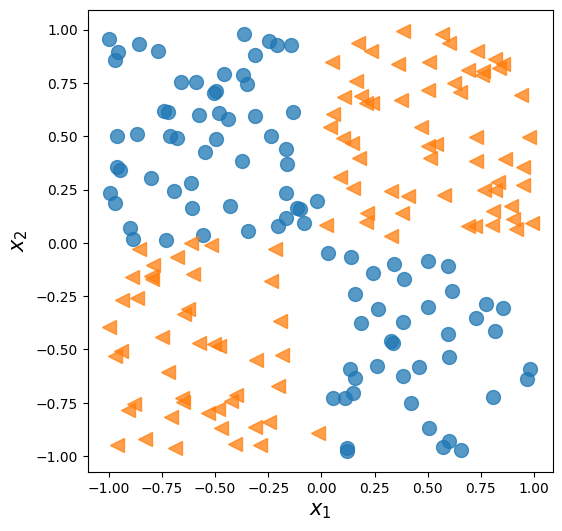

In [12]:
import matplotlib.pyplot as plt
import numpy as np
torch.manual_seed(1)
np.random.seed(1)
x = np.random.uniform(low=-1, high=1, size=(200, 2))
y = np.ones(len(x))
y[x[:, 0] * x[:, 1] < 0] = 0
n_train = 100
x_train = torch.tensor(x[:n_train], dtype=torch.float32)
y_train = torch.tensor(y[:n_train], dtype=torch.float32)
x_valid = torch.tensor(x[n_train:], dtype=torch.float32)
y_valid = torch.tensor(y[n_train:], dtype=torch.float32)
fig = plt.figure(figsize=(6, 6))
plt.plot(x[y==0, 0], x[y==0, 1], 'o', alpha=0.75, markersize=10)
plt.plot(x[y==1, 0], x[y==1, 1], '<', alpha=0.75, markersize=10)
plt.xlabel(r'$x_1$', size=15)
plt.ylabel(r'$x_2$', size=15)
plt.show()

The code results in the scatterplot above of the training and validation examples, shown with different markers based on their class label.

In the previous subsection, we covered the essential tools that we need to implement a classifier in PyTorch. We now need to decide what architecture we should choose for this task and dataset. As a general rule of thumb, the more layers we have, and the more neurons we have in each layer, the larger the capacity of the model will be. Here, the model capacity can be thought of as a measure of how readily the model can approximate complex functions. While having more parameters means the network can fit more complex functions, larger models are usually harder to train (and prone to overfitting). In practice, it is always a good idea to start with a simple model as a baseline, for example, a single-layer NN like logistic regression:

In [13]:
model = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)
model

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): Sigmoid()
)

After defining the model, we will initialize the cross-entropy loss function for binary classification and the SGD optimizer:

In [14]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

Next, we will create a data loader that uses a batch size of 2 for the train data:

In [15]:
from torch.utils.data import DataLoader, TensorDataset
train_ds = TensorDataset(x_train, y_train)
batch_size = 2
torch.manual_seed(1)
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

Now we will train the model for 200 epochs and record a history of training epochs:

In [16]:
torch.manual_seed(1)
num_epochs = 200
def train(model, num_epochs, train_dl, x_valid, y_valid):
    loss_hist_train = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs
    for epoch in range(num_epochs):
        for x_batch, y_batch in train_dl:
            pred = model(x_batch)[:, 0]
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_hist_train[epoch] += loss.item()
            is_correct = ((pred >= 0.5).float() == y_batch).float()
            accuracy_hist_train[epoch] += is_correct.mean()
        loss_hist_train[epoch] /= n_train/batch_size
        accuracy_hist_train[epoch] /= n_train/batch_size
        pred = model(x_valid)[:, 0]
        loss = loss_fn(pred, y_valid)
        loss_hist_valid[epoch] = loss.item()
        is_correct = ((pred >= 0.5).float() == y_valid).float()
        accuracy_hist_valid[epoch] = is_correct.mean()
    return loss_hist_train, loss_hist_valid, \
        accuracy_hist_train, accuracy_hist_valid

history = train(model, num_epochs, train_dl, x_valid, y_valid)

Notice that the history of training epochs includes the train loss and validation loss and the train accuracy and validation accuracy, which is useful for visual inspection after training. In the following code, we will plot the learning curves, including the training and validation loss, as well as their accuracies.

The following code will plot the training performance:

Text(0.5, 0, 'Epochs')

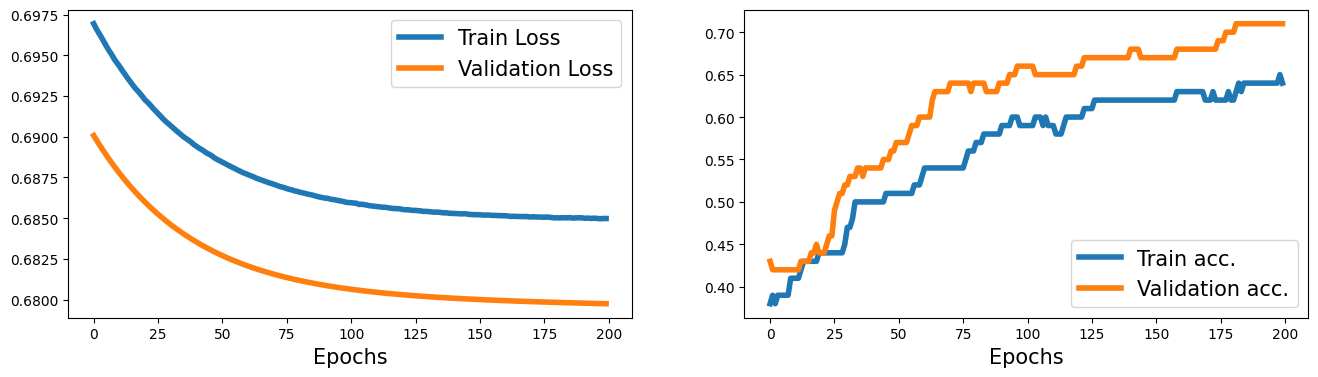

In [17]:
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Train Loss', 'Validation Loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)
ax = fig.add_subplot(1, 2, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Train acc.', 'Validation acc.'], fontsize=15)
ax.set_xlabel('Epochs', size=15)

As we can see, a simple model with no hidden layer can only derive a linear decision boundary, which is unable to solve the XOR problem. As a consequence, we can observe that the loss terms for both the training and the validation datasets are very high, and the classification accuracy is very low.

To derive a nonlinear decision boundary, we can add one or more hidden layers connected via nonlinear activation functions. The universal approximation theorem states that a feedforward NN with a single hidden layer and a relatively large number of hidden units can approximate arbitrary continuous functions relatively well. Thus, one approach for tackling the XOR problem more satisfactorily is to add a hidden layer and compare different numbers of hidden units until we observe satisfactory results on the validation dataset. Adding more hidden units would correspond to increasing the width of a layer.

Alternatively, we can also add more hidden layers, which will make the model deeper. The advantage of making a network deeper rather than wider is that fewer parameters are required to achieve a comparable model capacity. However, a downside of deep models is that deep models are prone to vanishing and exploding gradients, which  make them harder to train.

In the following example, we will take a look at the results of a feedforward NN with two hidden layers:

In [18]:
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.015)
model

Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=1, bias=True)
  (5): Sigmoid()
)

We can repeat the previous code for visualization, which produces the following:

Text(0.5, 0, 'Epochs')

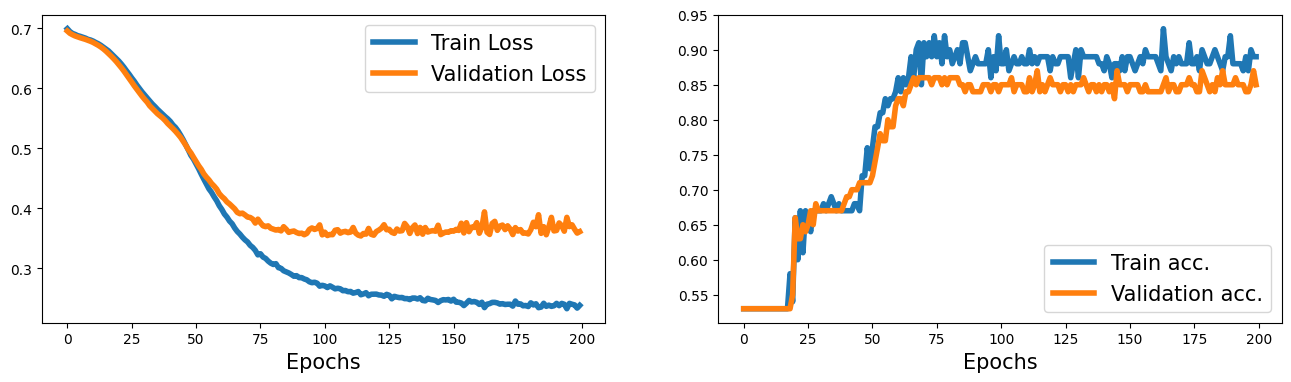

In [19]:
history = train(model, num_epochs, train_dl, x_valid, y_valid)

fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Train Loss', 'Validation Loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)
ax = fig.add_subplot(1, 2, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Train acc.', 'Validation acc.'], fontsize=15)
ax.set_xlabel('Epochs', size=15)

Now, we can see that the model is able to derive a nonlinear decision boundary for this data, and the model reaches 89 percent accuracy on the training dataset. The validation dataset's accuracy is 85 percent, which indicates that the model is slightly overfitting.

### Making Model Building More Flexible with nn.Module

In the previous example, we used the PyTorch Sequential class to create a fully connected NN with multiple layers. This is a very common and convenient way of building models. However, it unfrotunately doesn't allow us to create more complex models that have multiple input, output, or intermediate branches. That's where the nn.Module comes in handy.

The alternative way to build complex models is by subclassing nn.Module. In this approach, we create a new class derived from nn.Module and define the method, __init__() as a constructor. The forward() method is used to specify the forward pass. In the constructor function, __init__(), we define the layers as attributes of the class so that they can be accessed via the self reference attribute. Then, in the forward() method, we specify how these layers are to be used in the forward pass of the NN. The code for defining a new class that implements the previous model is as follows:

In [20]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        l1 = nn.Linear(2, 4)
        a1 = nn.ReLU()
        l2 = nn.Linear(4, 4)
        a2 = nn.ReLU()
        l3 = nn.Linear(4, 1)
        a3 = nn.Sigmoid()
        l = [l1, a1, l2, a2, l3, a3]
        self.module_list = nn.ModuleList(l)

    def forward(self, x):
        for f in self.module_list:
            x = f(x)
        return x

    def predict(self, x):
        x = torch.tensor(x, dtype=torch.float32)
        pred = self.forward(x)[:, 0]
        return (pred >= 0.5).float()


Notice that we put all layers in nn.ModuleList object, which is just a list object composed of nn.Module items. This makes the code more readable and easier to follow.

To compute the decision boundary of our model, we need to add a predict() method in the MyModule class. It will return the predicted class (0 or 1) for a sample.

Once we define an instance of this new class, we can train it as we did previously:

In [21]:
model = MyModule()
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.015)
history = train(model, num_epochs, train_dl, x_valid, y_valid)

The following code will plot the training performance along with the decision region bias:

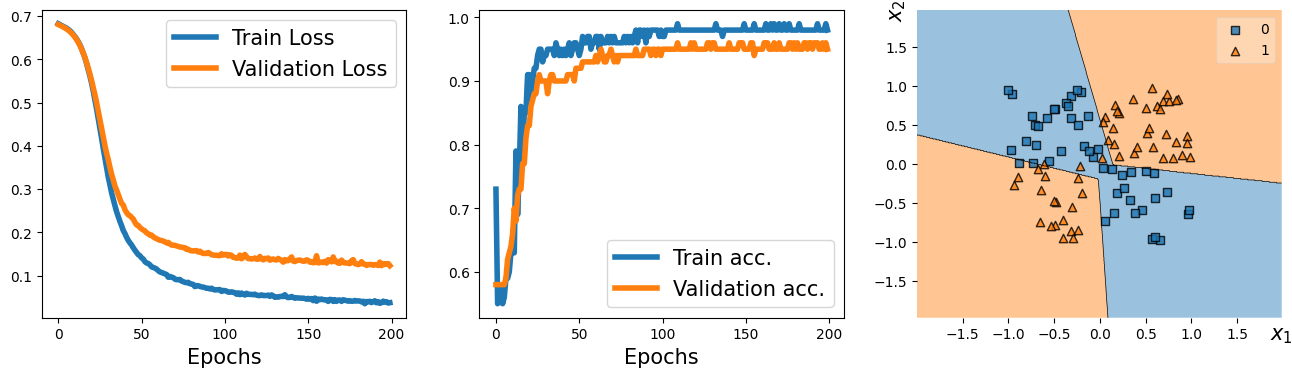

In [22]:
from mlxtend.plotting import plot_decision_regions
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Train Loss', 'Validation Loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)
ax = fig.add_subplot(1, 3, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Train acc.', 'Validation acc.'], fontsize=15)
ax.set_xlabel('Epochs', size=15)
ax = fig.add_subplot(1, 3, 3)
plot_decision_regions(X=x_valid.numpy(),
                      y=y_valid.numpy().astype(np.int64),
                      clf=model)
ax.set_xlabel(r'$x_1$', size=15)
ax.xaxis.set_label_coords(1, -0.025)
ax.set_ylabel(r'$x_2$', size=15)
ax.yaxis.set_label_coords(-0.025, 1)
plt.show()

### Writing Custom Layers in PyTorch

In cases where we want to define a new layer that is not already supported by PyTorch, we can define a new class derived from the nn.Module class. This is especially useful when designing a new layer or customizing an existing layer.

To illustrate the concept of implementing custom layers, let's consider a simple example, Imagine we want to define a new layer that computes $w(x + \epsilon) + b$, where $\epsilon$ refers to a random variable as a noise variable. To implement this computation, we define a new class as a subclass of nn.Module. For this new class, we have to define both the constructor __init__() method and the forward() method. In the constructor, we define the variables and the other required tensors for our customized layer. We can create variables and initialieze them in the constructor if the input_size is given to the constructor. Alternatively, we can delay the variable initialization (for instance, if we do not know the exact input shape upfront) and delegate it to another method for late variable creation.

To look at a concrete example, we are going to define a new layer called NoisyLinear, which implements the computation $w(x + \epsilon) + b$, which was mentioned in the preceding paragraph:

In [23]:
class NoisyLinear(nn.Module):
    def __init__(self, input_size, output_size, 
                 noise_stddev=0.1):
        super().__init__()
        w = torch.Tensor(input_size, output_size)
        self.w = nn.Parameter(w)
        nn.init.xavier_uniform_(self.w)
        b = torch.Tensor(output_size).fill_(0)
        self.b = nn.Parameter(b)
        self.noise_stddev = noise_stddev

    def forward(self, x, training=False):
        if training:
            noise = torch.normal(0.0, self.noise_stddev, x.shape)
            x_new = torch.add(x, noise)
        else:
            x_new = x
        return torch.add(torch.mm(x_new, self.w), self.b)


In this constructor, we have added an argument, noise_stddev, to specify the standard deviation for the distribution of $\epsilon$, which is sampled from a Gaussian distribution. Furthermore, notice that in the forward() method, we have used an additional argument, training=False. We use it to distinguish whether the layer is used during training or only for prediction (this is sometimes also called inference) or evaluation. Also, there are certain methods that behave differently in training and prediction modes. We will encounter an example of such a method, Dropout, in the upcoming chapters. In the previous code snippet, we also specified that the random vector, $\epsilon$, was to be generated and added to the input during training only and not used for inference or evaluation.

Before we go a step further and use our custom NoisyLinear layer in a model, let's test it in the context of a simple example.

1. In the following code, we will define a new instance of this layer, and execute it on an input tensor. Then, we will call the layer three times on the same input tensor:

In [24]:
torch.manual_seed(1)
noisy_layer = NoisyLinear(4, 2)
x = torch.zeros((1, 4))
print(noisy_layer(x, training=True))
print(noisy_layer(x, training=True))
print(noisy_layer(x, training=False))

tensor([[ 0.1154, -0.0598]], grad_fn=<AddBackward0>)
tensor([[ 0.0432, -0.0375]], grad_fn=<AddBackward0>)
tensor([[0., 0.]], grad_fn=<AddBackward0>)


Note that the outputs for the first two calls differ because NoisyLinear layer added random noise to the input tensor. The third call outputs [0, 0] as we didn't add noise by specifying training=False.

2. Now, let's create a new model similar to the previous one for solving the XOR classification task. As before, we will use the nn.Module class for model building, but this time, we will use our NoisyLinear layer as the first hidden layer of the multilayer perceptron. The code is as follows:

In [25]:
class MyNoisyModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = NoisyLinear(2, 4, 0.07)
        self.a1 = nn.ReLU()
        self.l2 = nn.Linear(4, 4)
        self.a2 = nn.ReLU()
        self.l3 = nn.Linear(4, 1)
        self.a3 = nn.Sigmoid()

    def forward(self, x, training=False):
        x = self.l1(x, training)
        x = self.a1(x)
        x = self.l2(x)
        x = self.a2(x)
        x = self.l3(x)
        x = self.a3(x)
        return x

    def predict(self, x):
        x = torch.tensor(x, dtype=torch.float32)
        pred = self.forward(x)[:, 0]
        return (pred >= 0.5).float()

torch.manual_seed(1)
model = MyNoisyModule()
model

MyNoisyModule(
  (l1): NoisyLinear()
  (a1): ReLU()
  (l2): Linear(in_features=4, out_features=4, bias=True)
  (a2): ReLU()
  (l3): Linear(in_features=4, out_features=1, bias=True)
  (a3): Sigmoid()
)

3. Similarly, we will train the model as we did previously. At this time, to compute the prediction on the training batch, we use pred = model(x_batch, True)[:, 0] instead of pred = model(x_batch)[:, 0]:

In [26]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.015)
torch.manual_seed(1)
loss_hist_train = [0] * num_epochs
accuracy_hist_train = [0] * num_epochs
loss_hist_valid = [0] * num_epochs
accuracy_hist_valid = [0] * num_epochs
for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch, True)[:, 0]
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_hist_train[epoch] += loss.item()
        is_correct = (
            (pred >= 0.5).float() == y_batch
        ).float()
        accuracy_hist_train[epoch] += is_correct.mean()
    loss_hist_train[epoch] /=n_train/batch_size
    accuracy_hist_train[epoch] /= n_train/batch_size
    pred = model(x_valid)[:, 0]
    loss = loss_fn(pred, y_valid)
    loss_hist_valid[epoch] = loss.item()
    is_correct = ((pred >= 0.5).float() == y_valid).float()
    accuracy_hist_valid[epoch] += is_correct.mean()

After the model is trained, we can plot the losses, accuracies, and the decision boundary:

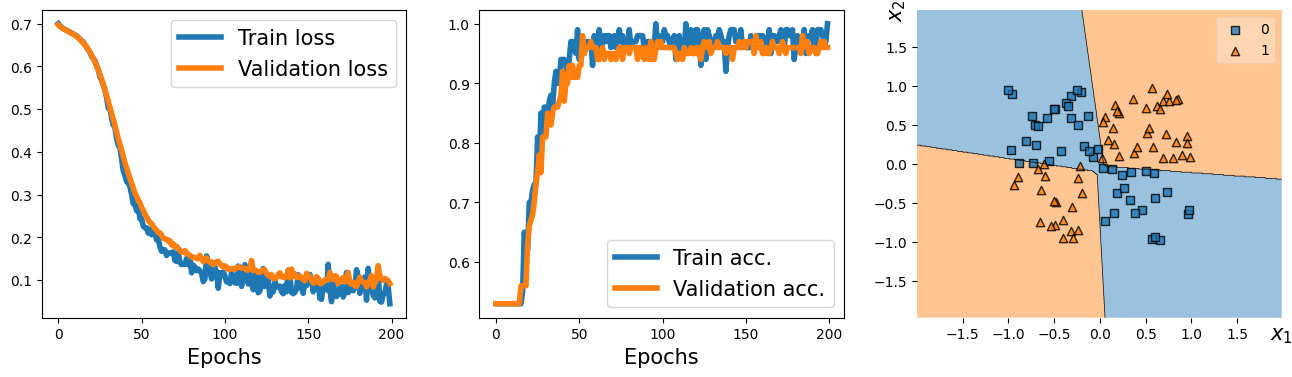

In [27]:
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(loss_hist_train, lw=4)
plt.plot(loss_hist_valid, lw=4)
plt.legend(['Train loss', 'Validation loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)
ax = fig.add_subplot(1, 3, 2)
plt.plot(accuracy_hist_train, lw=4)
plt.plot(accuracy_hist_valid, lw=4)
plt.legend(['Train acc.', 'Validation acc.'], fontsize=15)
ax.set_xlabel('Epochs', size=15)
ax = fig.add_subplot(1, 3, 3)
plot_decision_regions(
    X=x_valid.numpy(),
    y=y_valid.numpy().astype(np.int64),
    clf=model
)
ax.set_xlabel(r'$x_1$', size=15)
ax.xaxis.set_label_coords(1, -0.025)
ax.set_ylabel(r'$x_2$', size=15)
ax.yaxis.set_label_coords(-0.025, 1)
plt.show()

Here, our goal was to learn how to define a new custom layer subclassed from nn.Module and to use it as we would use any other standard torch.nn layer. Although, with this particular example, NoisyLinear did not help to improve the performance, please keep in mind that our objective was to mainly learn how to write a customized layer from scratch. In general, writing a new customized layer can be useful in other applcations, for example, if you develop a new algorithm that depends on a new layer beyond the existing ones.

### Project One - Predicting the Fuel Efficiency of a Car

So far, in this chapter, we have mostly focused on the torch.nn module. We used nn.Sequential to construct the models for simplicity. Then, we made model building more flexible with nn.Module and implemented feedforward NNs, to which we added customized layers. In this seciton, we will work on a real-world project of predicting the fuel efficiency of a car in miles per gallon (MPG). We will cover the underlying steps in machine learning tasks, such as data preprocessing, feature engineering, training, prediction (inference), and evaluation.

#### Working with Feature Columns

In machine learning and deep learning applications, we can encounter various differrent types of features: continuous, unordered categorical (nominal), and ordered categorical (ordinal). We covered different types of features and learned how to handle each type. Note that while numeric data can be either continous or discrete, we specifically refer to continous data of floating point type.

Sometimes, feature sets are comprised of a mixture of different feature types. For example, the features model year, cylinders, displacement, horsepower, weight, acceleration, and origin were obtained from the Auto MPG dataset, which is a common machine learning benchmark dataset for predicting the fuel efficiency of a car in MPG. We are going to treat five features from the Auto MPG dataset (number of cylinders, displacement, horsepower, weight and accelaration) as numeric features. The model year can be regarded as an ordered categorical (ordinal) feature. Lastly, the manufacturing origin can be regarded as an unordered categorical (nominal) feature with three possible discrete values, 1, 2, and 3, which correspond to the US, Europe, and Japan, respectively.

Let's first load the data and apply the necessary preprocessing steps, including dropping the incomplete rows, partitioning the dataset into training and test datasets, as well as standardizing the continuous features:

In [28]:
import pandas as pd
url = 'http://archive.ics.uci.edu/ml/' \
      'machine-learning-databases/auto-mpg/auto-mpg.data'

column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower',
                'Weight', 'Acceleration', 'Model Year', 'Origin']

df = pd.read_csv(url, names=column_names, 
                 na_values = '?', comment='\t',
                 sep=" ", skipinitialspace=True)

df = df.dropna()
df = df.reset_index(drop=True)

from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(
    df, train_size=0.8, random_state=1
)
train_stats = df_train.describe().transpose()

numeric_column_names = [
    'Cylinders', 'Displacement',
    'Horsepower', 'Weight',
    'Acceleration'
]

df_train_norm, df_test_norm = df_train.copy(), df_test.copy()
df_train_norm[numeric_column_names] = \
    df_train_norm[numeric_column_names].astype(float)
df_test_norm[numeric_column_names] = \
    df_test_norm[numeric_column_names].astype(float)
for col in numeric_column_names:
    mean = train_stats.loc[col, 'mean']
    std = train_stats.loc[col, 'std']
    df_train_norm.loc[:, col] =  \
        (df_train_norm.loc[:, col] - mean)/std
    df_test_norm.loc[:, col] =  \
        (df_test_norm.loc[:, col] - mean)/std
df_train_norm.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
203,28.0,-0.824303,-0.901020,-0.736562,-0.950031,0.255202,76,3
255,19.4,0.351127,0.413800,-0.340982,0.293190,0.548737,78,1
72,13.0,1.526556,1.144256,0.713897,1.339617,-0.625403,72,1
235,30.5,-0.824303,-0.891280,-1.053025,-1.072585,0.475353,77,1
37,14.0,1.526556,1.563051,1.636916,1.470420,-1.359240,71,1


The pandas DataFrame that we created via the previous code snippet contains five columns with values of the type float. These columns will constitute the continuous features.

Next, let's group the rather fine grained model year (ModelYear) information into buckets to simplify the learning task for the model that we are going to train later. Concretely, we are going to assign each car into one of four year buckets, as follows:

$$
\mathrm{bucket} =
\begin{cases}
0 & \text{if } \mathrm{year} < 73,\\
1 & \text{if } 73 \le \mathrm{year} < 76,\\
2 & \text{if } 76 \le \mathrm{year} < 79,\\
3 & \text{if } \mathrm{year} \ge 79.
\end{cases}
$$

Note that the chosen intervals were selected arbitarily to illustrate the concepts of "bucketing". In order to group the cars into these buckets, we will first define three cut-off values: [73, 76, 79] for the modeal year feature. These cut-off values are used to specify half-closed intervals, for instance, $(-\infty, 73)$, $[73, 76)$, $[76, 79)$ and $[79, \infty)$. Then, the original numeric features will be passed to the torch.bucketize function to generate the indices of the buckets. The code is as follows:

In [29]:
boundaries = torch.tensor([73, 76, 79])
v = torch.tensor(df_train_norm['Model Year'].values)
df_train_norm['Model Year Bucketed'] = torch.bucketize(
    v, boundaries, right=True
    )
v = torch.tensor(df_test_norm['Model Year'].values)
df_test_norm['Model Year Bucketed'] = torch.bucketize(
    v, boundaries, right=True
    )
numeric_column_names.append('Model Year Bucketed')

We added this bucketized feature column to the Python list numeric_column_names. 

Next, we will proceed with defining a list for the unordered categorical feature, Origin. In PyTorch, there are two ways to work with a categorical feature: using an embedding layer via nn.Embedding or using one-hot-encoded vectors (also called indicator). In the encoding approach, for example, index 0 will be encoded as [1, 0, 0], index 1 will be encoded as [0, 1, 0] and so on. On the other hand, the embedding layer maps each index to a vector of random numbers of the type float, which can be trained. (We can think of the embedding layer as a more efficient implementation of a one-hot encoding multiplied with a trainable weight matrix.)

When the number of categories is large, using the embedding layer with fewer dimensions than the number of categories can improve the performance.

In the following code snippet, we will use the one-hot-encoding approach on the categorical feature in order to convert it into the dense format:

In [30]:
from torch.nn.functional import one_hot
total_origin = len(set(df_train_norm['Origin']))
origin_encoded = one_hot(torch.from_numpy(
    df_train_norm['Origin'].values) % total_origin)
x_train_numeric = torch.tensor(
    df_train_norm[numeric_column_names].values)
x_train = torch.cat([x_train_numeric, origin_encoded], 1).float()
origin_encoded = one_hot(torch.from_numpy(
    df_test_norm['Origin'].values) % total_origin)
x_test_numeric = torch.tensor(
    df_test_norm[numeric_column_names].values)
x_test = torch.cat([x_test_numeric, origin_encoded], 1).float()

C:\Users\Kaan Oram\AppData\Local\Temp\ipykernel_41748\3575271784.py:3: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  origin_encoded = one_hot(torch.from_numpy(


After encoding the categorical feature into a three-dimensional dense feature, we concatenated it with the numeric features we processed in the previous step. Finally, we will create the label tensors from the ground truth MPG values as follows:

In [31]:
y_train = torch.tensor(df_train_norm['MPG'].values).float()
y_test = torch.tensor(df_test_norm['MPG'].values).float()

In this section, we have covered the most common approaches for preprocessing and creating features in PyTorch.

### Training a DNN Regression Model

Now, after constructing the mandatory features and labels, we will create a data loader that uses a batch size of 8 for the train data:

In [32]:
train_ds = TensorDataset(x_train, y_train)
batch_size = 8
torch.manual_seed(1)
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

Next, we will build a model with two fully connected layers where one has 8 hidden units and another has 4:

In [33]:
hidden_units = [8, 4]
input_size = x_train.shape[1]
all_layers = []
for hidden_unit in hidden_units:
    layer = nn.Linear(input_size, hidden_unit)
    all_layers.append(layer)
    all_layers.append(nn.ReLU())
    input_size = hidden_unit
all_layers.append(nn.Linear(hidden_units[-1], 1))
model = nn.Sequential(*all_layers)
model

Sequential(
  (0): Linear(in_features=9, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=1, bias=True)
)

After defining the model, we will define MSE loss function for regression and use stochastic gradient descent for optimization:

In [34]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

Now we will train the model for 200 epochs and display the train loss for every 20 epochs:

In [35]:
torch.manual_seed(1)
num_epochs = 200
log_epochs = 20
for epoch in range(num_epochs):
    loss_hist_train = 0
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)[:, 0]
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_hist_train += loss.item()
    if epoch % log_epochs == 0:
        print(f'Epoch {epoch} Loss '
              f'{loss_hist_train/len(train_dl):.4f}')

Epoch 0 Loss 536.1047
Epoch 20 Loss 8.4361
Epoch 40 Loss 7.8695
Epoch 60 Loss 7.1891
Epoch 80 Loss 6.7062
Epoch 100 Loss 6.7599
Epoch 120 Loss 6.3124
Epoch 140 Loss 6.6864
Epoch 160 Loss 6.7648
Epoch 180 Loss 6.2156


After 200 epochs, the train loss was around 5. We can now evaluate the regression performance of the trained model on the test dataset. To predict the target values on new data points, we can feed their features to the model:

In [36]:
with torch.no_grad():
    pred = model(x_test.float())[:, 0]
    loss = loss_fn(pred, y_test)
    print(f'Test MSE: {loss.item():.4f}')
    print(f'Test MAE: {nn.L1Loss()(pred, y_test).item():.4f}')

Test MSE: 9.6133
Test MAE: 2.1211


The MSE on the test set is 9.6 and the mean absolute error (MAE) is 2.1. After this regression project, we will work on a classification project in the next section.

### Project Two - Classifying MNIST Handwritten Digits

For this classification project, we are going to categorize MNIST handwritten digits. In the previous section, we covered the four essential steps for machine learning in PyTorch in detail, which we will need to repeat in this section.

First, we are going to load the MNIST dataset using the torchvision module.

1. The setup step includes loading the dataset and specifying the hyperparameters (the size of the train set and test set, and the size of mini-batches):

In [37]:
import torchvision
from torchvision import transforms

image_path = './'
transform = transforms.Compose([
    transforms.ToTensor()
])
mnist_train_dataset = torchvision.datasets.MNIST(
    root=image_path, train=True,
    transform=transform, download=False
)
mnist_test_dataset = torchvision.datasets.MNIST(
    root=image_path, train=False,
    transform=transform, download=False
)
batch_size = 64
torch.manual_seed(1)
train_dl = DataLoader(mnist_train_dataset,
                      batch_size, shuffle=True)

Here, we constructed a data loader with batches of 64 samples. Next, we will preprocess the loaded datasets.

2. We preprocess the input features and the labels. The features in this project are the pixels of the images we read from Step 1. We defined a custom transformation using torchvision.transforms.Compose. In this simple case, our transformation consisted only of one method, ToTensor(). The ToTensor() method converts the pixel features into a floating type tensor and also normalizes the pixes from the [0, 255] to [0, 1] range. The labels are integers from 0 to 9 representing ten digits. Hence, we don't need to do any scaling or futher conversion. Note that we can access the raw pixels using the data attribute, and don't forget to scale them to the range [0, 1]. We will construct the model in the next step once the data is preprocessed.

3. Construct the NN model:

In [38]:
hidden_units = [32, 16]
image_size = mnist_train_dataset[0][0].shape
input_size = image_size[0] * image_size[1] * image_size[2]
all_layers = [nn.Flatten()]
for hidden_unit in hidden_units:
    layer = nn.Linear(input_size, hidden_unit)
    all_layers.append(layer)
    all_layers.append(nn.ReLU())
    input_size = hidden_unit
all_layers.append(nn.Linear(hidden_units[-1], 10))
model = nn.Sequential(*all_layers)
model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=32, bias=True)
  (2): ReLU()
  (3): Linear(in_features=32, out_features=16, bias=True)
  (4): ReLU()
  (5): Linear(in_features=16, out_features=10, bias=True)
)

Note that the model starts with a flatten layer that flattens an input image into a one-dimensional tensor. This is because the input images are in the shape of [1, 28, 28]. The model has two hidden layers, with 32 and 16 units respectively. And it ends with with an output layer of ten units representing ten classes, activated by a softmax function. In the next step, we will train the model on the train set and evaluate it on the test set.

4. Use the model for training, evaluation and prediction:

In [39]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
torch.manual_seed(1)
num_epochs = 20
for epoch in range(num_epochs):
    accuracy_hist_train = 0
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        is_correct = (
            torch.argmax(pred, dim=1) == y_batch
        ).float()
        accuracy_hist_train += is_correct.sum()
    accuracy_hist_train /= len(train_dl.dataset)
    print(f'Epoch {epoch} Accuracy '
          f'{accuracy_hist_train:.4f}')

Epoch 0 Accuracy 0.8531
Epoch 1 Accuracy 0.9287
Epoch 2 Accuracy 0.9413
Epoch 3 Accuracy 0.9506
Epoch 4 Accuracy 0.9558
Epoch 5 Accuracy 0.9592
Epoch 6 Accuracy 0.9627
Epoch 7 Accuracy 0.9650
Epoch 8 Accuracy 0.9674
Epoch 9 Accuracy 0.9690
Epoch 10 Accuracy 0.9710
Epoch 11 Accuracy 0.9729
Epoch 12 Accuracy 0.9739
Epoch 13 Accuracy 0.9750
Epoch 14 Accuracy 0.9764
Epoch 15 Accuracy 0.9777
Epoch 16 Accuracy 0.9779
Epoch 17 Accuracy 0.9798
Epoch 18 Accuracy 0.9806
Epoch 19 Accuracy 0.9813


We used the cross-entropy loss function for multiclass classification and the Adam optimizer for gradient descent. We trained the model for 20 epochs and displayed the train accuracy for every epoch. The trained model reached an accuracy of 98.1 percent  on the training set and we will evaluate it on the testing set:

In [40]:
pred = model(mnist_test_dataset.data / 255.)
is_correct = (
    torch.argmax(pred, dim=1) == 
    mnist_test_dataset.targets
).float()
print(f'Test accuracy: {is_correct.mean():.4f}')

Test accuracy: 0.9647


The test accuracy is 96.5 percent. We have learned how to solve a classification problem using PyTorch.

### Higher-Level PyTorch APIs: a Short Introduction to PyTorch-Lightning

In recent years, the PyTorch community developed several different libraries and APIs on top of PyTorch. Notable examples include fastai, Catalyst, PyTorch Lightning, and PyTorch-Ignite.

In this section, we will explore PyTorch Lightning (Lightning for short), which is a widely used PyTorch library that makes training deep neural networks simpler by removing much of the boilerplate code. However, while Lightning's focus lies in simplicity and flexibility, it also allows us to use many advanced features such as multi_GPU support and fast low-precision training.

In an earlier section, we implemented a multilayer perceptron for classifying handwritten digits in the MNIST dataset. In the next subsections, we will reimplement this classifier using Lightning.

#### Setting Up the PyTorch Lightning Model

We start by implementing the model, which we train in the next subsections. Defining a model for Lightning is relatively straightforward as it is based on regular Python and PyTorch code. All that is required to implement a Lightning model is to use the LightningModule instead of the regular PyTorch module. To take advanatage of PyTorch's convenience functions, such as the trainer API and automatic logging, we just define a few specifically named methods, which we will see in the following code:

In [41]:
import pytorch_lightning as pl
import torch
import torch.nn as nn

from torchmetrics import Accuracy

class MultiLayerPerceptron(pl.LightningModule):
    def __init__(self, image_shape=(1, 28, 28), hidden_units=(32, 16)):
        super().__init__()

        # new PL attributes
        self.train_acc = Accuracy(task="multiclass", num_classes=10)
        self.valid_acc = Accuracy(task="multiclass", num_classes=10)
        self.test_acc = Accuracy(task="multiclass", num_classes=10)

        # Model similar to previous section:
        input_size = image_shape[0] * image_shape[1] * image_shape[2]
        all_layers = [nn.Flatten()]
        for hidden_unit in hidden_units:
            layer = nn.Linear(input_size, hidden_unit)
            all_layers.append(layer)
            all_layers.append(nn.ReLU())
            input_size = hidden_unit

        all_layers.append(nn.Linear(hidden_units[-1], 10))
        self.model = nn.Sequential(*all_layers)

    def forward(self, x):
        x = self.model(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = nn.functional.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)
        self.train_acc.update(preds, y)
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        self.log("train_acc", self.train_acc.compute())
        self.train_acc.reset()

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = nn.functional.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)
        self.valid_acc.update(preds, y)
        self.log('valid_loss', loss, prog_bar=True)
        self.log('valid_acc', self.valid_acc.compute(), prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = nn.functional.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)
        self.test_acc.update(preds, y)
        self.log('test_loss', loss, prog_bar=True)
        self.log('test_acc', self.test_acc.compute(), prog_bar=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=0.001)
        return optimizer


Let's now discuss the different methods one by one. As you can see, the __init__ constructor contains the same model code that we used in a previous subsection. What's new is that we added the accuracy attributes such as self.train_acc = Accuracy(task="multiclass", num_classes=10). These will allow us to track the accuracy during training. Accuracy was imported from the torchmetrics module, which should be automatically installed with Lightning. 

The forward method implements a simpel forward pass that returnt the logits (outputs of the last fully connected layer of our network before the softmax layer) when we call our model on the input data. The logits, computed via the forward method by calling self(x), are used for the training, validation, and test steps, which we'll describe next.

The training_step, on_train_epoch_end, validation_step, test_step, and configure_optimizers  methods are methods that are specifically recognized by Lightning. For instance, training_step defines a single forward pass during training, where we also keep track of the accuracy and loss so that we can analyze these later. Note that we compute the accuracy via self.train_acc.update(preds, y) but don't log it yet. The training_step method is executed on each individual batch during training, and via the training_epoch_end method, which is executed at the end of each training epoch, we compute the training set accuracy from the accuracy values we accumulated via training.

The validation_step and test_step methods define, analogous to the training_step method, how the validation and test evaluation process should be computed. Similar to training_step, each validation_step and test_step receives a single batch, which is why we log the accuracy via respective accuracy attributes derived from Accuracy of torchmetric. However, note that validation_step is only called in certain intervals, for example, after each training epoch. This is why we log the validation accuracy inside the validation step, whereas with the training accuracy, we log it after each training epoch, otherwise, the accuracy plot that we inspect later will look too noisy.

Finally, via the configure_optimizers method, we specify the optimizer used for training. The following two subsections will discuss how we can set up the dataset and how we can train the model.

#### Setting up the Data Loaders for Lightning

There are three main ways in which we can prepare the dataset for Lightning. We can:

- Make the dataset part of the model
- Set up the data loaders as usual and feed them to the fit method of a Lightning Trainer - the Trainer is introduced in the next subsection
- Create a LightningDataModule

Here, we are going to use a LightningDataModule, which is the most organized approach. The LightningDataModule consists of five main methods, as we can see in the following:

In [42]:
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torchvision.datasets import MNIST
from torchvision import transforms

class MnistDataModule(pl.LightningDataModule):
    def __init__(self, data_path='./'):
        super().__init__()
        self.data_path = data_path
        self.transform = transforms.Compose([
            transforms.ToTensor()
        ])

    def prepare_data(self):
        MNIST(root = self.data_path, download=True)

    def setup(self, stage=None):
        # stage is either 'fit', 'validate', 'test', or 'predict'
        mnist_all = MNIST(
            root=self.data_path,
            train=True,
            transform=self.transform,
            download=True
        )

        self.train, self.val = random_split(
            mnist_all, [55000, 5000], generator=torch.Generator().manual_seed(1)
        )

        self.test = MNIST(
            root=self.data_path,
            train=False,
            transform=self.transform,
            download=False
        )

    def train_dataloader(self):
        return DataLoader(self.train, batch_size=64, 
                          num_workers=4,
                          persistent_workers=True)

    def val_dataloader(self):
        return DataLoader(self.val, batch_size=64, 
                          num_workers=4,
                          persistent_workers=True)

    def test_dataloader(self):
        return DataLoader(self.test, batch_size=64, 
                          num_workers=4,
                          persistent_workers=True)

In the prepare_data method, we define general steps, such as downloading the dataset. In the setup method, we define the datasets used for training, validation, and testing. Note that MNIST does not have a dedicated valiation split, which is why we use the random_split function to divide the 60,000-example training set into 55,000 examples for training and 5,000 examples for validation.

The data loader methods are self-explanatory and define how the respective datasets are loaded. Now, we can initialize the data module and use it for training, validation, and testing in the next subsections:

In [43]:
torch.manual_seed(1)
mnist_dm = MnistDataModule()

#### Training the Model Using the PyTorch Lightning Trainer Class

Now we can reap the rewards from setting up the model with the specifically named methods, as well as the Lightning data module. Lightning implements a Trainer class that makes the training model super convenient by taking care of all the intermediate steps, such as calling zero_grad(), backward(), and optimizer.step() for us. Also, as a bonus, it lets us easily specify one or more GPUs to suse (if available):

In [44]:
import logging
import warnings
from pytorch_lightning.loggers import TensorBoardLogger

tb_logger = TensorBoardLogger("lightning_logs", name="mnist")
trainer = pl.Trainer(max_epochs=10, logger=tb_logger)

logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
warnings.filterwarnings(
    "ignore", message=r".*LeafSpec.*deprecated.*"
)

mnistclassifier = MultiLayerPerceptron()

if torch.cuda.is_available():
    trainer = pl.Trainer(max_epochs=10, 
                         accelerator='gpu',
                         devices=1,
                         enable_model_summary=False,
                         logger=tb_logger)
else:
    trainer = pl.Trainer(max_epochs=10, 
                         enable_model_summary=False,
                         logger=tb_logger)

trainer.fit(mnistclassifier, datamodule=mnist_dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Epoch 9: 100%|██████████| 860/860 [00:05<00:00, 162.53it/s, v_num=1, train_loss=0.260, valid_loss=0.166, valid_acc=0.936]  


#### Evaluating the Model Using TensorBoard

In the previous section, we experienced the convenience of the Trainer class. Another nice feature of Lightning is its logging capabilities. Recall that we specified several self.log steps in our Lightning model earlier. After, and even during training, we can visualize them in TensorBoard. 

By default, Lightning tracks the training in a subfolder named lightning_logs. To visualize the training runs, you can execute the following code in the command-line terminal, which will open TensorBoard in your browser:

Alternatively, if you are running the code in a Jupyter notebook, you can add the following code to a Jupyter notebook cell to show the TensorBoard dashboard in the notebook directly:

Once we are finished with training, we can evaluate the model on the test set using the following code:

In [45]:
trainer.test(model=mnistclassifier, datamodule=mnist_dm)

Testing DataLoader 0: 100%|██████████| 157/157 [00:00<00:00, 230.21it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9505840539932251
        test_loss           0.14711593091487885
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.14711593091487885, 'test_acc': 0.9505840539932251}]

The resulting test set performance, after training for 15 epochs in total, is approximately 95 percent. Note that PyTorch Lightning automatically saves the model for us. If you want to reuse the model later, you can conveniently load it via the following code:

In [ ]:
model = MultiLayerPerceptron.load_from_checkpoint("path/to/checkpoint.ckpt")